In [1]:
from utils import *
NOTEBOOK_ID = '01'

In [2]:
out_file = f'{VIRUS_DIR}/virus_metadata.csv'
if not os.path.isfile(out_file):
    cols = ["Genome","Accession","RefSeq type","Source information","Number of segments","Genome length","Number of proteins","Genome Neighbors","Host","Date completed","Date updated"]
    with open(f"{METADATA_DIR}/taxid10239.tbl", "r") as ncbi_file:
        lines = ncbi_file.readlines()[2:]
    realm, strain, substrain = '', '', '' # instantiate variables
    ncbi_df = pd.DataFrame(columns=cols)
    for i, x in tqdm(enumerate(lines),total=len(lines)):
        x = x.replace('\n','')
        if 'proteins: 1' in x: # ignore viruses with one protein
            continue
        elif '          ' in x: # handle substrain
            substrain = x.replace('          ','').split('\t')
            curr_row = dict(zip(cols, substrain))
        elif '    ' in x: # handle strain
            strain = x.replace('    ','').split('\t')
            curr_row = dict(zip(cols, strain))
        else: # handle realm
            realm = x
            continue
        curr_row['realm'] = realm
        ncbi_df = pd.concat([ncbi_df, pd.DataFrame([curr_row])]).reset_index(drop=True)
    ncbi_df = ncbi_df[ncbi_df['Accession'].notnull()]
    ncbi_df = ncbi_df.query('Accession != "-"')
    ncbi_df['Filename'] = ncbi_df['Genome'].apply(lambda x: x.replace('  ','').replace('[','').replace(']','').replace('.','').replace(' ','_').replace('/','').replace(':',''))
    ncbi_df['Genome length'] = ncbi_df['Genome length'].apply(lambda x: x.replace(' nt',''))
    ncbi_df = ncbi_df[ncbi_df['Host'].isin(['land plants', 'plants','invertebrates, land plants'])].reset_index(drop=True)
    ncbi_df.to_csv(out_file,index=False)
else:
    ncbi_df = pd.read_csv(out_file)
ncbi_df.head()

,Genome,Accession,RefSeq type,Source information,Number of segments,Genome length,Number of proteins,Genome Neighbors,Host,Date completed,Date updated,realm,Filename
0,Ageratum conyzoides associated symptomless alp...,NC_024710,complete,isolate:Okra,-,1437,1,7,land plants,08/20/2014,08/13/2018,Alphasatellitidae,Ageratum_conyzoides_associated_symptomless_alp...
1,Ageratum conyzoides symptomless alphasatellite,NC_028116,complete,isolate:WOK80,-,1381,1,7,land plants,10/30/2015,08/13/2018,Alphasatellitidae,Ageratum_conyzoides_symptomless_alphasatellite
2,Ageratum enation alphasatellite,NC_019547,complete,isolate:Poppy (1),-,1378,1,20,land plants,11/21/2012,08/13/2018,Alphasatellitidae,Ageratum_enation_alphasatellite
3,Ageratum leaf curl Cameroon alphasatellite,NC_014744,complete,isolate:SatA7,-,1383,3,4,land plants,12/01/2010,08/14/2018,Alphasatellitidae,Ageratum_leaf_curl_Cameroon_alphasatellite
4,Ageratum yellow vein China alphasatellite,NC_023443,complete,isolate:Sn3,-,1365,1,-,land plants,02/13/2014,08/13/2018,Alphasatellitidae,Ageratum_yellow_vein_China_alphasatellite


In [3]:
DOWNLOAD_GENOMES = False
if DOWNLOAD_GENOMES:
    LEN_DF = len(ncbi_df)
    t = trange(LEN_DF, desc='Bar desc', leave=True)
    for i,row in ncbi_df.iterrows():
        accession = row['Accession']
        filename = row['Filename']
        t.set_description(f"File {i} of {LEN_DF}: {filename}")
        t.refresh()
        os.system(f'wget \
                  -q "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={accession}&rettype=genbank&retmode=text" \
                    -O {GENOME_DIR}/{filename}.gbk')

In [4]:
CONVERT_GBK = False
if CONVERT_GBK:
    virus_files = [file.split('/')[-1].replace('.gbk','') for file in glob(f'{GENOME_DIR}/*')]
    ncbi_df['Filename'].isin(virus_files).value_counts()
    accession_map = dict(zip(ncbi_df['Accession'],ncbi_df['Filename']))

    def convert_gbk_faa(input_gbk,output_faa):
        gbk_filename = input_gbk
        faa_filename = output_faa
        input_handle  = open(gbk_filename, "r")
        output_handle = open(faa_filename, "w")
        for seq_record in SeqIO.parse(input_handle, "genbank") :
            print("Converting %s" % seq_record.id)
            for seq_feature in seq_record.features :
                if seq_feature.type == "CDS" :
                    assert len(seq_feature.qualifiers['translation'])==1
                    try: 
                        output_handle.write(f">{seq_feature.qualifiers['locus_tag'][0]} | {accession_map[seq_record.name]} | {seq_record.name}\n{seq_feature.qualifiers['translation'][0]}\n")
                    except:
                        output_handle.write(f"> None | {accession_map[seq_record.name]} | {seq_record.name}\n{seq_feature.qualifiers['translation'][0]}\n")
        output_handle.close()
        input_handle.close()

    for gbk_filename in glob(f'{GENOME_DIR}/*.gbk'):
        faa_filename = gbk_filename.replace('.gbk','.faa')
        convert_gbk_faa(gbk_filename,faa_filename)
    os.system(f'cat {GENOME_DIR}/*.faa > {VIRUS_DIR}/plant_viral_proteins.faa')

In [5]:
out_file = f'{ANALYSIS_DIR}/cdhit_clustering.csv'
if not os.path.isfile(out_file):
    out_dir = '../02-OUTPUT/xx-sandbox/cd_hit'
    data = []
    faa_file = f'{VIRUS_DIR}/plant_viral_proteins.faa'
    handle = faa_file.split('/')[-1].replace('.faa','')
    total_seqs = count_fasta_sequences(faa_file)
    data.append([1.0,total_seqs,1.0])
    for threshold in np.arange(0.99, 0.62, -0.01):
        threshold = round(threshold,2)
        os.system(f'cd-hit -i {faa_file} -o {out_dir}/clustered_{handle}_{threshold}.faa -c {threshold}')
        seqs = count_fasta_sequences(f'{out_dir}/clustered_{handle}_{threshold}.faa')
        data.append([threshold,seqs,seqs/total_seqs])
    similarity_df = pd.DataFrame(data,columns=['threshold','num_seqs','norm_count'])
    similarity_df.to_csv(out_file,index=False)
else:
    similarity_df = pd.read_csv(out_file)
similarity_df.head()

,threshold,num_seqs,norm_count
0,1.00,5607,1.000000
1,0.99,5344,0.953094
2,0.98,5268,0.939540
3,0.97,5180,0.923845
4,0.96,5094,0.908507


3278.0
4.0
223.0


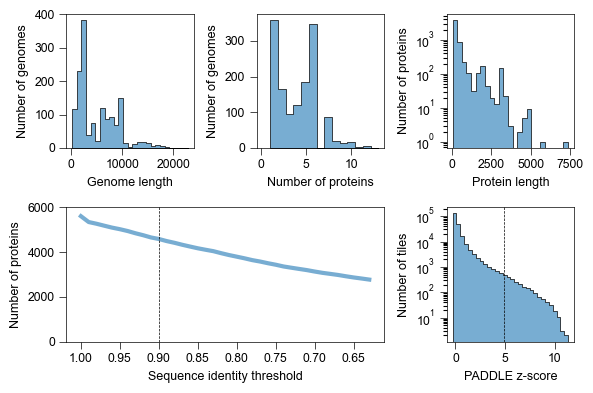

In [6]:
fig = plt.figure(figsize=(6, 4))
gs = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ncbi_df = pd.read_csv(f'{VIRUS_DIR}/plant_virus_metadata.csv')
g = sns.histplot(data=ncbi_df['Genome length'].astype(int),bins=25,element='step',alpha=0.6,edgecolor='black',ax=ax1,linewidth=0.5)
print(ncbi_df['Genome length'].astype(int).median())
g.set(ylabel='Number of genomes')

ax2 = fig.add_subplot(gs[0, 1])
g = sns.histplot(data=ncbi_df['Number of proteins'].replace('-',np.nan).dropna().astype(int),element='step',alpha=0.6,edgecolor='black',ax=ax2,linewidth=0.5)
print(ncbi_df['Number of proteins'].replace('-',np.nan).dropna().astype(int).median())
g.set(xlabel='Number of proteins',ylabel='Number of genomes')
xmin,xmax = g.get_xlim()
g.set(xlim=(-0.5,xmax))
g.xaxis.set_major_locator(MultipleLocator(5))

ax3 = fig.add_subplot(gs[0, 2])
df = fasta_to_dataframe(f'{VIRUS_DIR}/plant_viral_proteins.faa')
g = sns.histplot(df['sequence'].apply(len),bins=25,element='step',edgecolor='black',alpha=0.6,ax=ax3,linewidth=0.5)
print(df['sequence'].apply(len).median())
g.set(yscale='log',xlabel='Protein length',ylabel='Number of proteins')
g.xaxis.set_major_locator(MultipleLocator(2500))

ax4 = fig.add_subplot(gs[1, 0:2])
g = sns.lineplot(data=similarity_df,x='threshold',y='num_seqs',linewidth=3,alpha=0.6,ax=ax4)
ymin,ymax = g.get_ylim()
plt.gca().invert_xaxis()
g.set(xlabel='Sequence identity threshold',ylabel='Number of proteins',ylim=(0,6000))
g.xaxis.set_major_locator(MultipleLocator(0.05))
g.axvline(x=0.9,linestyle='--',linewidth=0.5,color='black')

ax5 = fig.add_subplot(gs[1, 2])
paddle_df = pd.read_csv(f'{INFERENCE_DIR}/01-PADDLE/PADDLE_predictions.csv')
g = sns.histplot(data=paddle_df,x='zscore',ax=ax5,alpha=0.6,bins=30,element='step',edgecolor='black',linewidth=0.5)
g.set(xlabel='PADDLE z-score',ylabel='Number of tiles',yscale='log')
g.axvline(x=4.9,color='black',linestyle='--',linewidth=0.5)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-viral_overview.svg',**FIG_PARAMS)